In [1]:
rating_vars = {
    2010: [
        "contractid", "org_type", "contract_name", "org_marketing",
        "breastcancer_screen", "rectalcancer_screen", "cv_diab_cholscreen",
        "glaucoma_test", "monitoring", "flu_vaccine", "pn_vaccine",
        "physical_health", "mental_health", "osteo_test", "physical_monitor",
        "primaryaccess", "osteo_manage", "diab_healthy", "bloodpressure",
        "ra_manage", "copd_test", "bladder", "falling", "nodelays",
        "doctor_communicate", "carequickly", "customer_service",
        "overallrating_care", "overallrating_plan", "complaints_plan",
        "appeals_timely", "appeals_review", "leave_plan", "audit_problems",
        "hold_times", "info_accuracy", "ttyt_available",
    ],
    2011: [
        "contractid", "org_type", "contract_name", "org_marketing",
        "breastcancer_screen", "rectalcancer_screen", "cv_cholscreen",
        "diab_cholscreen", "glaucoma_test", "monitoring", "flu_vaccine",
        "pn_vaccine", "physical_health", "mental_health", "osteo_test",
        "physical_monitor", "primaryaccess", "osteo_manage", "diabetes_eye",
        "diabetes_kidney", "diabetes_bloodsugar", "diabetes_chol",
        "bloodpressure", "ra_manage", "copd_test", "bladder", "falling",
        "nodelays", "doctor_communicate", "carequickly", "customer_service",
        "overallrating_care", "overallrating_plan", "complaints_plan",
        "appeals_timely", "appeals_review", "corrective_action",
        "hold_times", "info_accuracy", "ttyt_available",
    ],
    2012: [
        "contractid", "org_type", "org_parent", "org_marketing",
        "breastcancer_screen", "rectalcancer_screen", "cv_cholscreen",
        "diab_cholscreen", "glaucoma_test", "flu_vaccine", "pn_vaccine",
        "physical_health", "mental_health", "physical_monitor", "primaryaccess",
        "bmi_assess", "older_medication", "older_function", "older_pain",
        "osteo_manage", "diabetes_eye", "diabetes_kidney", "diabetes_bloodsugar",
        "diabetes_chol", "bloodpressure", "ra_manage", "bladder", "falling",
        "readmissions", "nodelays", "carequickly", "customer_service",
        "overallrating_care", "overallrating_plan", "complaints_plan",
        "access_problems", "leave_plan", "appeals_timely", "appeals_review",
        "ttyt_available",
    ],
    2013: [
        "contractid", "org_type", "contract_name", "org_marketing", "org_parent",
        "breastcancer_screen", "rectalcancer_screen", "cv_cholscreen",
        "diab_cholscreen", "glaucoma_test", "flu_vaccine", "physical_health",
        "mental_health", "physical_monitor", "bmi_assess", "older_medication",
        "older_function", "older_pain", "osteo_manage", "diabetes_eye",
        "diabetes_kidney", "diabetes_bloodsugar", "diabetes_chol", "bloodpressure",
        "ra_manage", "bladder", "falling", "readmissions", "nodelays", "carequickly",
        "customer_service", "overallrating_care", "overallrating_plan",
        "coordination", "complaints_plan", "access_problems", "leave_plan",
        "improve", "appeals_timely", "appeals_review", "ttyt_available",
        "enroll_timely",
    ],
    2014: [
        "contractid", "org_type", "contract_name", "org_marketing", "org_parent",
        "breastcancer_screen", "rectalcancer_screen", "cv_cholscreen",
        "diab_cholscreen", "glaucoma_test", "flu_vaccine", "physical_health",
        "mental_health", "physical_monitor", "bmi_assess", "older_medication",
        "older_function", "older_pain", "osteo_manage", "diabetes_eye",
        "diabetes_kidney", "diabetes_bloodsugar", "diabetes_chol", "bloodpressure",
        "ra_manage", "bladder", "falling", "readmissions", "nodelays", "carequickly",
        "customer_service", "overallrating_care", "overallrating_plan",
        "coordination", "complaints_plan", "access_problems", "leave_plan",
        "improve", "appeals_timely", "appeals_review", "ttyt_available",
    ],
    2015: [
        "contractid", "org_type", "contract_name", "org_marketing", "org_parent",
        "rectalcancer_screen", "cv_cholscreen", "diab_cholscreen", "flu_vaccine",
        "physical_health", "mental_health", "physical_monitor", "bmi_assess",
        "specialneeds_manage", "older_medication", "older_function", "older_pain",
        "osteo_manage", "diabetes_eye", "diabetes_kidney", "diabetes_bloodsugar",
        "diabetes_chol", "bloodpressure", "ra_manage", "bladder", "falling",
        "readmissions", "nodelays", "carequickly", "customer_service",
        "overallrating_care", "overallrating_plan", "coordination",
        "complaints_plan", "leave_plan", "improve", "appeals_timely",
        "appeals_review",
    ],
}

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

BASE = Path("../../..")
OUT_DIR = BASE / "data" / "output"

# Columns that are NOT measure variables
exclude_cols = {"contractid", "org_type", "contract_name",
                "org_marketing", "org_parent"}

# Extract just the measure columns per year
measure_vars = {
    yr: [c for c in cols if c not in exclude_cols]
    for yr, cols in rating_vars.items()
}

# Load all years and compute raw_rating
all_years = {}
for year in range(2010, 2016):
    df = pd.read_csv(OUT_DIR / f"ma_data_{year}_final.csv", low_memory=False)

    # Compute raw_rating as row-wise mean of available measure columns
    cols = [c for c in measure_vars[year] if c in df.columns]
    df["raw_rating"] = df[cols].mean(axis=1, skipna=True)

    all_years[year] = df
    print(f"{year}: {len(df):,} rows | "
          f"raw_rating non-null: {df['raw_rating'].notna().sum():,} | "
          f"Star_Rating non-null: {df['Star_Rating'].notna().sum():,}")

2010: 112,856 rows | raw_rating non-null: 98,145 | Star_Rating non-null: 63,320
2011: 70,184 rows | raw_rating non-null: 59,534 | Star_Rating non-null: 57,421
2012: 69,770 rows | raw_rating non-null: 67,830 | Star_Rating non-null: 61,027
2013: 70,930 rows | raw_rating non-null: 70,062 | Star_Rating non-null: 67,684
2014: 65,095 rows | raw_rating non-null: 63,294 | Star_Rating non-null: 61,771
2015: 67,505 rows | raw_rating non-null: 64,012 | Star_Rating non-null: 62,776


In [3]:
# Question 1: Summary Stats Table for mean star rating, mean number of enrollments, and mean market share for plans by year
rows = []
for year in range(2010, 2016):
    df = all_years[year]

    # Mean star rating computed only over plans that have a rating
    rated = df[df["Star_Rating"].notna()]

    rows.append({
        "Year":              year,
        "Mean Star Rating":  rated["Star_Rating"].mean(),
        "Mean Enrollment":   df["enrollment"].mean(),
        "Mean Market Share": df["market_share"].mean(),
        "Number of Plans":   len(df),
    })

q1_table = pd.DataFrame(rows).set_index("Year")
q1_table = q1_table.round(3)

print("\nQuestion 1: Summary Statistics by Year")
print("="*65)
print(q1_table.to_string()) 


Question 1: Summary Statistics by Year
      Mean Star Rating  Mean Enrollment  Mean Market Share  Number of Plans
Year                                                                       
2010             2.964          252.245              0.065           112856
2011             3.241          336.362              0.085            70184
2012             3.329          372.366              0.084            69770
2013             3.525          384.188              0.080            70930
2014             3.771          431.075              0.078            65095
2015             3.940          466.571              0.077            67505


In [4]:
# Question 2: Plans without a star rating
rows = []
for year in range(2010, 2016):
    df = all_years[year]

    unrated = df[df["Star_Rating"].isna()]

    rows.append({
        "Year":              year,
        "Mean Enrollment":   unrated["enrollment"].mean(),
        "Mean Market Share": unrated["market_share"].mean(),
        "Number of Plans":   len(unrated),
    })

q2_table = pd.DataFrame(rows).set_index("Year")
q2_table = q2_table.round(3)

print("\nQuestion 2: Summary Statistics for Plans Without a Star Rating")
print("="*65)
print(q2_table.to_string())


Question 2: Summary Statistics for Plans Without a Star Rating
      Mean Enrollment  Mean Market Share  Number of Plans
Year                                                     
2010          109.950              0.067            49536
2011          172.682              0.091            12763
2012          162.435              0.053             8743
2013          182.393              0.050             3246
2014          248.227              0.043             3324
2015          312.343              0.041             4729


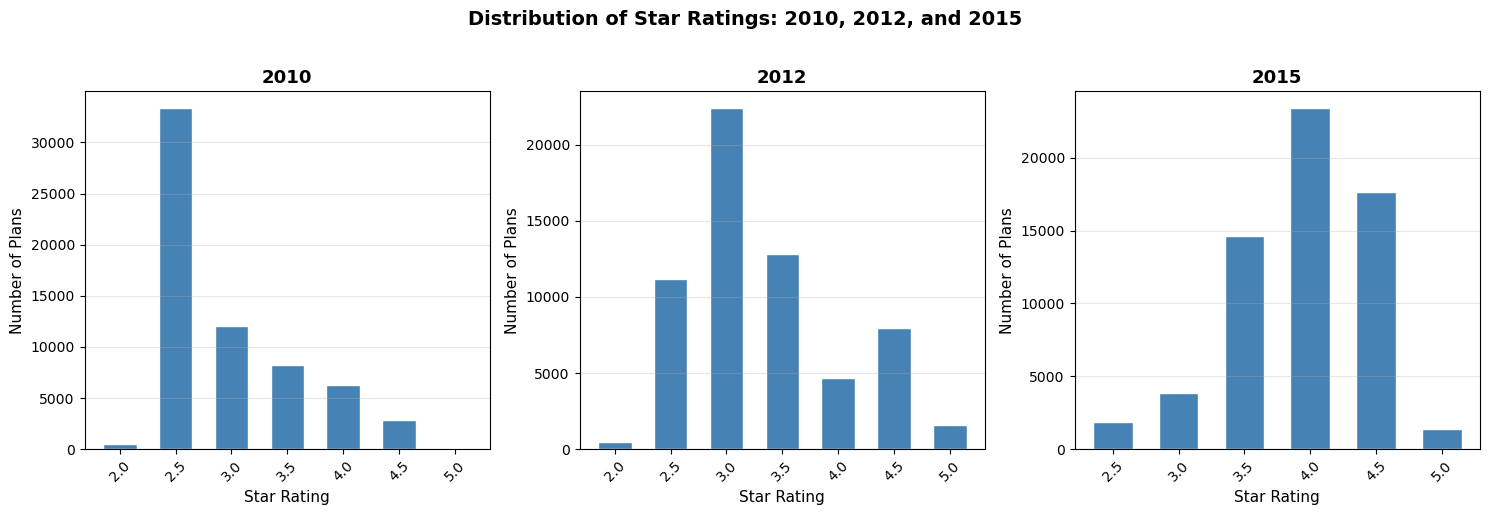

Plot saved!


In [5]:
# Question 3: Bar Graphs (2010, 2012, 2015)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

years_to_plot = [2010, 2012, 2015]

for ax, year in zip(axes, years_to_plot):
    df = all_years[year]
    rated = df[df["Star_Rating"].notna()]

    counts = (
        rated["Star_Rating"]
        .value_counts()
        .sort_index()
    )

    ax.bar(counts.index.astype(str), counts.values,
           color="steelblue", edgecolor="white", width=0.6)
    ax.set_title(f"{year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Star Rating", fontsize=11)
    ax.set_ylabel("Number of Plans", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribution of Star Ratings: 2010, 2012, and 2015",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "star_rating_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [6]:
# OLS Regression for Question 4
results = {}

for year in range(2010, 2016):
    df = all_years[year].copy()

    # Drop rows missing market_share or Star_Rating
    df = df[df["market_share"].notna() & df["Star_Rating"].notna()].copy()

    # Create star rating indicators
    # Excluded category: Star_Rating <= 2.5
    df["star_3"]    = (df["Star_Rating"] == 3.0).astype(int)
    df["star_35"]   = (df["Star_Rating"] == 3.5).astype(int)
    df["star_4"]    = (df["Star_Rating"] == 4.0).astype(int)
    df["star_45up"] = (df["Star_Rating"] >= 4.5).astype(int)

    model = smf.ols(
        "market_share ~ star_3 + star_35 + star_4 + star_45up",
        data=df
    ).fit()

    results[year] = model
    print(f"\n{year}: n={len(df):,} | R²={model.rsquared:.4f}")


2010: n=20,409 | R²=0.0007

2011: n=20,493 | R²=0.0126

2012: n=22,577 | R²=0.0294

2013: n=25,531 | R²=0.0168

2014: n=24,530 | R²=0.0070

2015: n=23,920 | R²=0.0050


In [7]:
# Question 4: OLS Regression results table 
coef_labels = {
    "Intercept":  "Intercept (≤2.5 stars)",
    "star_3":     "3 Stars",
    "star_35":    "3.5 Stars",
    "star_4":     "4 Stars",
    "star_45up":  "4.5+ Stars",
}

rows_coef = []
rows_se   = []

for label_key, label_name in coef_labels.items():
    coef_row = {"Variable": label_name}
    se_row   = {"Variable": f"({label_name} SE)"}

    for year in range(2010, 2016):
        model = results[year]
        if label_key in model.params:
            coef_row[str(year)] = round(model.params[label_key], 4)
            se_row[str(year)]   = f"({round(model.bse[label_key], 4)})"
        else:
            coef_row[str(year)] = "—"
            se_row[str(year)]   = "—"

    rows_coef.append(coef_row)
    rows_se.append(se_row)

# Interleave coefficient and SE rows
interleaved = []
for coef, se in zip(rows_coef, rows_se):
    interleaved.append(coef)
    interleaved.append(se)

q4_table = pd.DataFrame(interleaved).set_index("Variable")

print("\nQuestion 4: OLS Regression of Market Share on Star Rating Indicators")
print("="*75)
print(q4_table.to_string())


Question 4: OLS Regression of Market Share on Star Rating Indicators
                                 2010      2011      2012      2013      2014      2015
Variable                                                                               
Intercept (≤2.5 stars)         0.0623    0.0689    0.0568    0.0427    0.0497    0.0586
(Intercept (≤2.5 stars) SE)   (0.001)  (0.0018)  (0.0021)  (0.0024)  (0.0048)  (0.0038)
3 Stars                         0.004    0.0288    0.0549    0.0544    0.0218    0.0202
(3 Stars SE)                 (0.0017)  (0.0023)  (0.0025)  (0.0029)  (0.0051)  (0.0046)
3.5 Stars                      0.0034     0.022    0.0368     0.046    0.0425    0.0325
(3.5 Stars SE)               (0.0019)  (0.0027)  (0.0029)  (0.0027)  (0.0049)  (0.0041)
4 Stars                       -0.0001    0.0083    0.0038    0.0244    0.0247    0.0144
(4 Stars SE)                 (0.0021)  (0.0031)  (0.0036)  (0.0033)  (0.0051)   (0.004)
4.5+ Stars                    -0.0053   -0.0068   

In [8]:
# Saving the tables for pdf 
q1_table.to_csv(OUT_DIR / "hw3_q1_summary_stats.csv")
q2_table.to_csv(OUT_DIR / "hw3_q2_unrated_summary.csv")
q4_table.to_csv(OUT_DIR / "hw3_q4_regression.csv")
print("All tables saved to output directory.")

All tables saved to output directory.


In [9]:
# ATE Estimation (Question 5-10)

In [10]:
!pip install rdrobust rddensity

In [11]:
!pip install rdrobust

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from rdrobust import rdrobust, rdplot
from rddensity import rddensity, rdplotdensity

BASE = Path("../../..")
OUT_DIR = BASE / "data" / "output"

# Load 2010 data
ma_2010 = pd.read_csv(OUT_DIR / "ma_data_2010_final.csv", low_memory=False)

# Compute market share
ma_2010["mkt_share"] = ma_2010["enrollment"] / ma_2010["avg_enrolled"]

# Compute raw_rating (row-wise mean of measure columns)
measure_vars_2010 = [
    "breastcancer_screen", "rectalcancer_screen", "cv_diab_cholscreen",
    "glaucoma_test", "monitoring", "flu_vaccine", "pn_vaccine",
    "physical_health", "mental_health", "osteo_test", "physical_monitor",
    "primaryaccess", "osteo_manage", "diab_healthy", "bloodpressure",
    "ra_manage", "copd_test", "bladder", "falling", "nodelays",
    "doctor_communicate", "carequickly", "customer_service",
    "overallrating_care", "overallrating_plan", "complaints_plan",
    "appeals_timely", "appeals_review", "leave_plan", "audit_problems",
    "hold_times", "info_accuracy", "ttyt_available",
]
cols_present = [c for c in measure_vars_2010 if c in ma_2010.columns]
ma_2010["raw_rating"] = ma_2010[cols_present].mean(axis=1, skipna=True)

# Filter to rows where mkt_share is computable
ma_2010_rd = ma_2010[ma_2010["mkt_share"].notna()].copy()

print(f"Total 2010 rows: {len(ma_2010):,}")
print(f"Rows available for RD analysis: {len(ma_2010_rd):,}")
print(f"Star_Rating non-null: {ma_2010_rd['Star_Rating'].notna().sum():,}")
print(f"raw_rating non-null: {ma_2010_rd['raw_rating'].notna().sum():,}")
print(f"mkt_share non-null: {ma_2010_rd['mkt_share'].notna().sum():,}")


Total 2010 rows: 112,856
Rows available for RD analysis: 32,002
Star_Rating non-null: 20,409
raw_rating non-null: 27,477
mkt_share non-null: 32,002


In [12]:
# Question 5: Running variable and table of rounded-up plans 
thresholds = [
    (2.5,  3.0,  2.75,  "3-star"),
    (3.0,  3.5,  3.25,  "3.5-star"),
    (3.5,  4.0,  3.75,  "4-star"),
    (4.0,  4.5,  4.25,  "4.5-star"),
]

rows = []
for lower, upper, cutoff, label in thresholds:
    sub = ma_2010_rd[
        ma_2010_rd["Star_Rating"].isin([lower, upper]) &
        ma_2010_rd["raw_rating"].notna()
    ].copy()

    below = (sub["raw_rating"] < cutoff).sum()
    above = (sub["raw_rating"] >= cutoff).sum()

    rows.append({
        "Star Rating":        label,
        "Cutoff":             cutoff,
        "Plans Below Cutoff": below,
        "Plans Above Cutoff": above,
        "Total Plans":        len(sub),
    })

q5_table = pd.DataFrame(rows)
print("\nQuestion 5 (HW Q1): Plans Around Each Star Rating Threshold")
print("="*70)
print(q5_table.to_string(index=False))


Question 5 (HW Q1): Plans Around Each Star Rating Threshold
Star Rating  Cutoff  Plans Below Cutoff  Plans Above Cutoff  Total Plans
     3-star    2.75                8681                4578        13259
   3.5-star    3.25                4578                3201         7779
     4-star    3.75                3864                1690         5554
   4.5-star    4.25                3435                 194         3629


In [13]:
# Check what raw_rating values look like for plans near the 3-star and 3.5-star thresholds
for star, cutoff in [(3.0, 2.75), (3.5, 3.25)]:
    sub = ma_2010_rd[ma_2010_rd["Star_Rating"] == star].copy()
    print(f"\nStar_Rating == {star}: {len(sub):,} plans")
    print(f"  raw_rating stats:")
    print(sub["raw_rating"].describe().round(3).to_string())
    print(f"  raw_rating below cutoff ({cutoff}): {(sub['raw_rating'] < cutoff).sum():,}")
    print(f"  raw_rating above cutoff ({cutoff}): {(sub['raw_rating'] >= cutoff).sum():,}")
    print(f"  raw_rating missing: {sub['raw_rating'].isna().sum():,}")


Star_Rating == 3.0: 4,578 plans
  raw_rating stats:
count    4578.000
mean        2.991
std         0.144
min         2.750
25%         2.885
50%         3.000
75%         3.111
max         3.242
  raw_rating below cutoff (2.75): 0
  raw_rating above cutoff (2.75): 4,578
  raw_rating missing: 0

Star_Rating == 3.5: 3,201 plans
  raw_rating stats:
count    3201.000
mean        3.472
std         0.137
min         3.250
25%         3.355
50%         3.452
75%         3.567
max         3.731
  raw_rating below cutoff (3.25): 0
  raw_rating above cutoff (3.25): 3,201
  raw_rating missing: 0


In [14]:
for star, cutoff in [(3.0, 2.75), (3.5, 3.25), (4.0, 3.75), (4.5, 4.25)]:
    lower = star - 0.5
    sub = ma_2010_rd[
        ma_2010_rd["Star_Rating"].isin([lower, star]) &
        ma_2010_rd["raw_rating"].notna()
    ].copy()
    below = (sub["raw_rating"] < cutoff).sum()
    above = (sub["raw_rating"] >= cutoff).sum()
    print(f"\nThreshold {cutoff} ({lower} vs {star} stars):")
    print(f"  Plans below cutoff: {below:,}")
    print(f"  Plans above cutoff: {above:,}")
    print(f"  Total: {len(sub):,}")


Threshold 2.75 (2.5 vs 3.0 stars):
  Plans below cutoff: 8,681
  Plans above cutoff: 4,578
  Total: 13,259

Threshold 3.25 (3.0 vs 3.5 stars):
  Plans below cutoff: 4,578
  Plans above cutoff: 3,201
  Total: 7,779

Threshold 3.75 (3.5 vs 4.0 stars):
  Plans below cutoff: 3,864
  Plans above cutoff: 1,690
  Total: 5,554

Threshold 4.25 (4.0 vs 4.5 stars):
  Plans below cutoff: 3,435
  Plans above cutoff: 194
  Total: 3,629


In [15]:
# Question 6: RD estimate w/ bandwidth of 0.125 at 3-star and 3.5-star thresholds
def build_rd_sample(df, lower_star, upper_star, cutoff, bw=0.125):
    candidates = df[
        df["raw_rating"].notna() &
        df["Star_Rating"].notna() &
        df["Star_Rating"].isin([lower_star, upper_star])
    ].copy()

    match_mask = (
        ((candidates["Star_Rating"] == upper_star) &
         (candidates["raw_rating"] >= cutoff)) |
        ((candidates["Star_Rating"] == lower_star) &
         (candidates["raw_rating"] < cutoff))
    )
    sample = candidates[match_mask].copy()
    sample["score"] = sample["raw_rating"] - cutoff
    sample["treat"] = (sample["score"] >= 0).astype(int)
    sample["score_treat"] = sample["score"] * sample["treat"]

    # Filter to within bandwidth window
    sample = sample[sample["score"].between(-bw, bw)].copy()
    return sample

rd_3star  = build_rd_sample(ma_2010_rd, 2.5, 3.0, 2.75, bw=0.125)
rd_35star = build_rd_sample(ma_2010_rd, 3.0, 3.5, 3.25, bw=0.125)

print(f"3-star sample:   {len(rd_3star):,} plans")
print(f"3.5-star sample: {len(rd_35star):,} plans")

def run_rd(sample, label):
    # rdrobust for the main estimate
    est = rdrobust(
        y=sample["mkt_share"].values,
        x=sample["score"].values,
        c=0,
        h=0.125,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off"
    )
    coef  = float(est.coef.iloc[1, 0])
    ci_lo = float(est.ci.iloc[2, 0])
    ci_hi = float(est.ci.iloc[2, 1])

    # OLS on the bandwidth-filtered sample for intercept, N, R²
    bw_sample = sample[sample["score"].between(-0.125, 0.125)].copy()
    ols = smf.ols("mkt_share ~ treat + score + treat:score", data=bw_sample).fit()

    print(f"\n{label} (bandwidth=0.125):")
    print(f"  RD Estimate: {coef:.4f}  95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  Intercept:   {ols.params['Intercept']:.3f}")
    print(f"  Rounded:     {ols.params['treat']:.3f}")
    print(f"  N obs:       {int(ols.nobs):,}")
    print(f"  R²:          {ols.rsquared:.3f}")

    return {
        "Threshold":  label,
        "Intercept":  round(ols.params["Intercept"], 3),
        "Rounded":    round(ols.params["treat"], 3),
        "N obs":      int(ols.nobs),
        "R²":         round(ols.rsquared, 3),
        "RD Estimate (rdrobust)": round(coef, 4),
        "CI Lower":   round(ci_lo, 4),
        "CI Upper":   round(ci_hi, 4),
    }

results_q6 = []
results_q6.append(run_rd(rd_3star,  "3-star vs 2.5-star"))
results_q6.append(run_rd(rd_35star, "3.5-star vs 3-star"))

q6_table = pd.DataFrame(results_q6)
print("\nQuestion 6 (HW Q2): RD Estimates at Bandwidth = 0.125")
print("="*60)
print(q6_table.to_string(index=False))

3-star sample:   5,865 plans
3.5-star sample: 2,049 plans

3-star vs 2.5-star (bandwidth=0.125):
  RD Estimate: -0.0324  95% CI: [-0.0523, -0.0124]
  Intercept:   0.012
  Rounded:     0.031
  N obs:       5,865
  R²:          0.065

3.5-star vs 3-star (bandwidth=0.125):
  RD Estimate: -0.0711  95% CI: [-0.0964, -0.0458]
  Intercept:   0.100
  Rounded:     -0.034
  N obs:       2,049
  R²:          0.014

Question 6 (HW Q2): RD Estimates at Bandwidth = 0.125
         Threshold  Intercept  Rounded  N obs    R²  RD Estimate (rdrobust)  CI Lower  CI Upper
3-star vs 2.5-star      0.012    0.031   5865 0.065                 -0.0324   -0.0523   -0.0124
3.5-star vs 3-star      0.100   -0.034   2049 0.014                 -0.0711   -0.0964   -0.0458



Question 7: RD Sensitivity to Bandwidth Choice

3-star vs 2.5-star
 bandwidth  estimate  ci_lower  ci_upper
     0.100    0.0086   -0.0096    0.0268
     0.120   -0.0227   -0.0405   -0.0049
     0.125   -0.0324   -0.0523   -0.0124
     0.130   -0.0257   -0.0457   -0.0056
     0.140   -0.0039   -0.0211    0.0132
     0.150    0.0732    0.0611    0.0853

3.5-star vs 3-star
 bandwidth  estimate  ci_lower  ci_upper
     0.100   -0.0503   -0.0757   -0.0250
     0.120   -0.0825   -0.1088   -0.0562
     0.125   -0.0711   -0.0964   -0.0458
     0.130   -0.0697   -0.0949   -0.0446
     0.140   -0.0598   -0.0842   -0.0354
     0.150   -0.0852   -0.1107   -0.0597


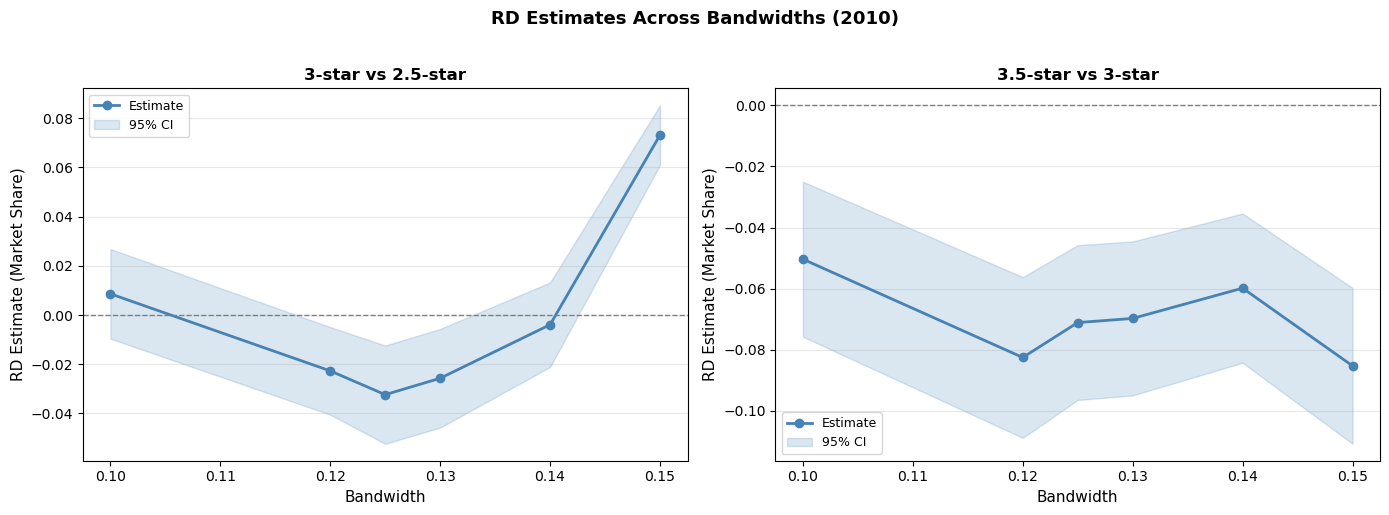

Plot saved!


In [16]:
# Question 7: Repeat RD estimates for bandwidths of 0.1, 0.12, 0.13, 0.14, and 0.15
bandwidths = [0.10, 0.12, 0.125, 0.13, 0.14, 0.15]

def rd_sensitivity(df, lower_star, upper_star, cutoff, label, bandwidths):
    records = []
    for bw in bandwidths:
        sample = build_rd_sample(df, lower_star, upper_star, cutoff, bw=bw)
        
        est = rdrobust(
            y=sample["mkt_share"].values,
            x=sample["score"].values,
            c=0,
            h=bw,
            p=1,
            kernel="uniform",
            vce="hc0",
            masspoints="off"
        )

        records.append({
            "bandwidth": bw,
            "threshold": label,
            "estimate":  float(est.coef.iloc[1, 0]),
            "ci_lower":  float(est.ci.iloc[2, 0]),
            "ci_upper":  float(est.ci.iloc[2, 1]),
        })
    return records

records_3  = rd_sensitivity(ma_2010_rd, 2.5, 3.0, 2.75, "3-star vs 2.5-star", bandwidths)
records_35 = rd_sensitivity(ma_2010_rd, 3.0, 3.5, 3.25, "3.5-star vs 3-star", bandwidths)
sens_df = pd.DataFrame(records_3 + records_35)

# Print sensitivity table
print("\nQuestion 7: RD Sensitivity to Bandwidth Choice")
print("="*60)
for threshold in ["3-star vs 2.5-star", "3.5-star vs 3-star"]:
    print(f"\n{threshold}")
    sub = sens_df[sens_df["threshold"] == threshold][
        ["bandwidth", "estimate", "ci_lower", "ci_upper"]
    ].round(4)
    print(sub.to_string(index=False))

# Plot: estimate + CI on y-axis, bandwidth on x-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, label in zip(axes, ["3-star vs 2.5-star", "3.5-star vs 3-star"]):
    sub = sens_df[sens_df["threshold"] == label]
    ax.plot(sub["bandwidth"], sub["estimate"], marker="o",
            color="steelblue", linewidth=2, label="Estimate")
    ax.fill_between(sub["bandwidth"], sub["ci_lower"], sub["ci_upper"],
                    alpha=0.2, color="steelblue", label="95% CI")
    ax.axhline(0, linestyle="--", color="grey", linewidth=1)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Bandwidth", fontsize=11)
    ax.set_ylabel("RD Estimate (Market Share)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("RD Estimates Across Bandwidths (2010)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "rd_bandwidth_sensitivity.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Plot saved!")                               

In [17]:
# Patch rddensity to fix pandas compatibility bug
import rddensity.rdbwdensity as _rdbw
import inspect, types

src = inspect.getsource(_rdbw.rdbwdensity)
src = src.replace(
    "Yc = pd.DataFrame(Y[abs(X)<=cn])",
    "Yc = pd.DataFrame(Y[np.array(abs(X))<=cn])"
)
exec(compile(src, "<patched>", "exec"), _rdbw.__dict__)

AttributeError: 'function' object has no attribute 'rdbwdensity'

In [ ]:
import rddensity.rdbwdensity as _rdbw
import inspect
print(inspect.getfile(_rdbw))

/Users/valeriehernandez/anaconda3/lib/python3.11/site-packages/rddensity/rdbwdensity.py


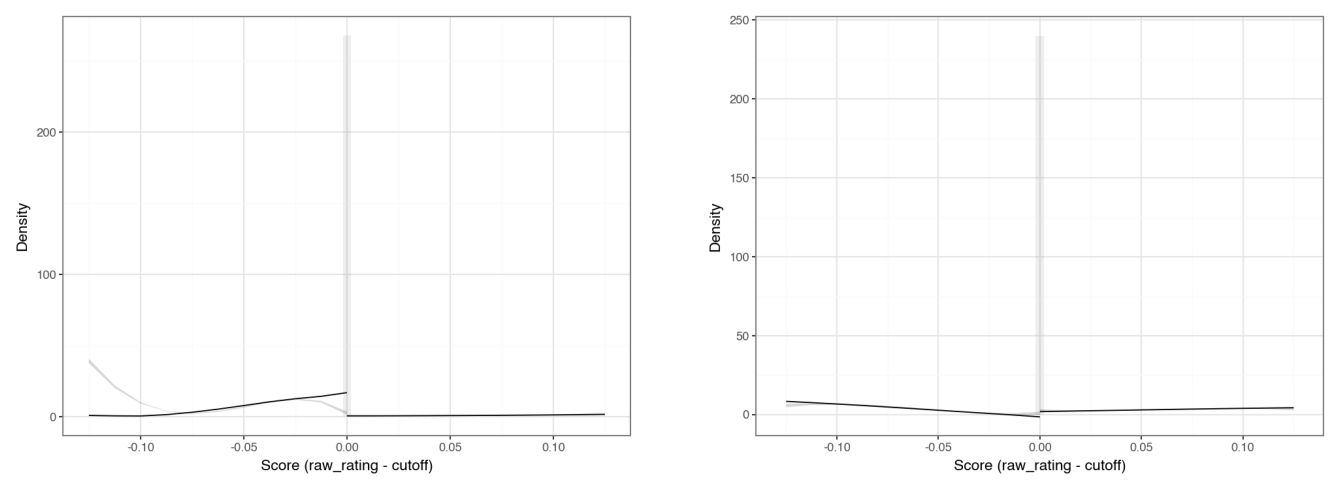

Plot saved!


In [18]:
# Question 8: Manipulation test
import io
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sample, label) in zip(axes, [
    (rd_3star,  "3-star vs 2.5-star (cutoff=2.75)"),
    (rd_35star, "3.5-star vs 3-star (cutoff=3.25)"),
]):
    # Pass as a clean pandas Series with reset index
    score_vals = pd.Series(
        sample["score"].values, 
        dtype=float
    ).reset_index(drop=True)
    
    dens = rddensity(score_vals, c=0)
    pval = float(dens.test["p_jk"])
    
    densplot = rdplotdensity(
        dens,
        score_vals,
        xlabel="Score (raw_rating - cutoff)",
        ylabel="Density",
        title=f"{label}\nManipulation test p-value: {pval:.3f}"
    )
    
    buf = io.BytesIO()
    densplot.save(buf, format="png", dpi=150)
    buf.seek(0)
    img = Image.open(buf)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "rd_manipulation_test.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [19]:
for sample, label in [(rd_3star, "3-star vs 2.5-star"), (rd_35star, "3.5-star vs 3-star")]:
    score_vals = pd.Series(sample["score"].values, dtype=float).reset_index(drop=True)
    dens = rddensity(score_vals, c=0)
    pval = float(dens.test["p_jk"])
    print(f"{label}: p-value = {pval:.4f}")

3-star vs 2.5-star: p-value = 0.0000
3.5-star vs 3-star: p-value = 0.0002


In [ ]:
# Question 9: Examining whether plans just above the threshold values have different characteristics than contracts just below the threshold
def check_balance(sample, cutoff_label, bandwidth=0.125):
    sub = sample[sample["score"].between(-bandwidth, bandwidth)].copy()
    sub["is_hmo"]    = sub["plan_type_plan"].str.contains(
        "HMO", case=False, na=False).astype(int)
    sub["has_partd"] = (sub["partd"] == "Yes").astype(int)
    results = []
    for outcome, label in [("is_hmo", "HMO Plan"), ("has_partd", "Has Part D")]:
        model = smf.ols(f"{outcome} ~ score + treat", data=sub).fit()
        coef  = float(model.params["treat"])
        pval  = float(model.pvalues["treat"])
        results.append({
            "Characteristic": label,
            "Threshold":      cutoff_label,
            "Coefficient":    round(coef, 4),
            "P-value":        round(pval, 4),
            "N":              len(sub),
        })
        print(f"  {label}: coef={coef:.4f}, p={pval:.4f}")
    return results

print("Balance check at 3-star threshold (bandwidth=0.125):")
bal_3  = check_balance(rd_3star,  "3-star vs 2.5-star")
print("\nBalance check at 3.5-star threshold (bandwidth=0.125):")
bal_35 = check_balance(rd_35star, "3.5-star vs 3-star")

balance_table = pd.DataFrame(bal_3 + bal_35)
print("\nQuestion 9: Covariate Balance Table")
print("="*65)
print(balance_table.to_string(index=False))

Balance check at 3-star threshold (bandwidth=0.125):
  HMO Plan: coef=0.6009, p=0.0000
  Has Part D: coef=0.4309, p=0.0000

Balance check at 3.5-star threshold (bandwidth=0.125):
  HMO Plan: coef=-0.5531, p=0.0000
  Has Part D: coef=-0.0431, p=0.2025

Question 9: Covariate Balance Table
Characteristic          Threshold  Coefficient  P-value    N
      HMO Plan 3-star vs 2.5-star       0.6009   0.0000 5865
    Has Part D 3-star vs 2.5-star       0.4309   0.0000 5865
      HMO Plan 3.5-star vs 3-star      -0.5531   0.0000 2049
    Has Part D 3.5-star vs 3-star      -0.0431   0.2025 2049


In [ ]:
# Question 9: Covariate Balance at Thresholds 
from scipy import stats

def balance_table_means(sample, cutoff_label, bandwidth=0.125):
    sub = sample[sample["score"].between(-bandwidth, bandwidth)].copy()
    sub["is_hmo"]    = sub["plan_type_plan"].str.contains("HMO", case=False, na=False).astype(int)
    sub["has_partd"] = (sub["partd"] == "Yes").astype(int)

    below = sub[sub["treat"] == 0]
    above = sub[sub["treat"] == 1]

    results = []
    for outcome, label in [("is_hmo", "HMO Plan"), ("has_partd", "Has Part D")]:
        mean_below = below[outcome].mean()
        mean_above = above[outcome].mean()
        diff = mean_above - mean_below
        tstat, pval = stats.ttest_ind(above[outcome], below[outcome])
        results.append({
            "Characteristic": label,
            "Threshold": cutoff_label,
            "Mean Below": round(mean_below, 4),
            "Mean Above": round(mean_above, 4),
            "Difference": round(diff, 4),
            "P-value": round(pval, 4),
            "N Below": len(below),
            "N Above": len(above)
        })
    return results

bal_means_3  = balance_table_means(rd_3star,  "3-star vs. 2.5-star")
bal_means_35 = balance_table_means(rd_35star, "3.5-star vs. 3-star")
balance_means_table = pd.DataFrame(bal_means_3 + bal_means_35)
balance_means_table

,Characteristic,Threshold,Mean Below,Mean Above,Difference,P-value,N Below,N Above
0,HMO Plan,3-star vs. 2.5-star,0.0269,0.6521,0.6252,0.0000,4767,1098
1,Has Part D,3-star vs. 2.5-star,0.5349,0.8625,0.3275,0.0000,4767,1098
2,HMO Plan,3.5-star vs. 3-star,0.6645,0.3759,-0.2886,0.0000,1070,979
3,Has Part D,3.5-star vs. 3-star,0.8757,0.8447,-0.0310,0.0431,1070,979


In [ ]:
print(rd_3star.columns.tolist())

['contractid', 'planid', 'fips', 'year', 'state_plan', 'county_plan', 'org_type_plan', 'plan_type_plan', 'partd', 'snp', 'eghp_plan', 'org_name_plan', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'enrollment', 'state_sa', 'county_sa', 'org_name_sa', 'org_type_sa', 'plan_type_sa', 'partial', 'eghp_sa', 'ssa', 'notes', 'avg_enrolled', 'avg_eligibles', 'ssa_pen', 'market_share', 'market_share_sq', 'hhi', 'breastcancer_screen', 'rectalcancer_screen', 'cv_diab_cholscreen', 'glaucoma_test', 'monitoring', 'flu_vaccine', 'pn_vaccine', 'physical_health', 'mental_health', 'osteo_test', 'physical_monitor', 'primaryaccess', 'osteo_manage', 'diab_healthy', 'bloodpressure', 'ra_manage', 'copd_test', 'bladder', 'falling', 'nodelays', 'doctor_communicate', 'carequickly', 'customer_service', 'overallrating_care', 'overallrating_plan', 'complaints_plan', 'appeals_timely', 'appeals_review', 'leave_plan', 'audit_problems', 'hold_times', 'info_accuracy', 'ttyt_available', 'new_contract

In [ ]:
# Question 10: Summarizing findings from question 5-9
print("\nQuestion 10: Summary of RD Findings")
print("="*65)
print("\nRD Estimates at Bandwidth = 0.125:")
print(q6_table.to_string(index=False))

print("\nBandwidth Sensitivity:")
# Manually build table without any pandas reshaping
thresholds = sens_df["threshold"].unique()
bandwidths = sorted(sens_df["bandwidth"].unique())
header = f"{'Bandwidth':<12}" + "".join(f"{t:<25}" for t in thresholds)
print(header)
for bw in bandwidths:
    row = f"{bw:<12}"
    for t in thresholds:
        val = sens_df[(sens_df["bandwidth"]==bw) & (sens_df["threshold"]==t)]["estimate"].values
        row += f"{round(float(val[0]),4):<25}" if len(val) > 0 else f"{'N/A':<25}"
    print(row)

print("\nCovariate Balance:")
print(balance_table[["Characteristic", "Threshold",
                      "Coefficient", "P-value"]].to_string(index=False))


Question 10: Summary of RD Findings

RD Estimates at Bandwidth = 0.125:
         Threshold  Estimate  CI Lower  CI Upper
3-star vs 2.5-star   -0.0324   -0.0523   -0.0124
3.5-star vs 3-star   -0.0711   -0.0964   -0.0458

Bandwidth Sensitivity:
Bandwidth   3-star vs 2.5-star       3.5-star vs 3-star       
0.1         0.0086                   -0.0503                  
0.12        -0.0227                  -0.0825                  
0.125       -0.0324                  -0.0711                  
0.13        -0.0257                  -0.0697                  
0.14        -0.0039                  -0.0598                  
0.15        0.0732                   -0.0852                  

Covariate Balance:
Characteristic          Threshold  Coefficient  P-value
      HMO Plan 3-star vs 2.5-star       0.6009   0.0000
    Has Part D 3-star vs 2.5-star       0.4309   0.0000
      HMO Plan 3.5-star vs 3-star      -0.5531   0.0000
    Has Part D 3.5-star vs 3-star      -0.0431   0.2025


#### Question 10: 
##### The regression discontinuity estimates suggest that increasing star ratings is associated with lower enrollment at the cutoffs examined, especially at the 3.5-star threshold. Based on the reuslts, tje 3.5-star thresholds shows a relatively stable negative effect whereas the 3-star rating threshold results are sensitive to the bandwidth.

In [ ]:
df.columns

Index(['contractid', 'planid', 'fips', 'year', 'state_plan', 'county_plan',
       'org_type_plan', 'plan_type_plan', 'partd', 'snp', 'eghp_plan',
       'org_name_plan', 'org_marketing_name', 'plan_name', 'parent_org',
       'contract_date', 'enrollment', 'state_sa', 'county_sa', 'org_name_sa',
       'org_type_sa', 'plan_type_sa', 'partial', 'eghp_sa', 'ssa', 'notes',
       'avg_enrolled', 'avg_eligibles', 'ssa_pen', 'market_share',
       'market_share_sq', 'hhi', 'rectalcancer_screen', 'cv_cholscreen',
       'diab_cholscreen', 'flu_vaccine', 'physical_health', 'mental_health',
       'physical_monitor', 'bmi_assess', 'specialneeds_manage',
       'older_medication', 'older_function', 'older_pain', 'osteo_manage',
       'diabetes_eye', 'diabetes_kidney', 'diabetes_bloodsugar',
       'diabetes_chol', 'bloodpressure', 'ra_manage', 'bladder', 'falling',
       'readmissions', 'nodelays', 'carequickly', 'customer_service',
       'overallrating_care', 'overallrating_plan', 'coordin